# Walmart Sales Forecasting - EDA and Model Training

**Dataset:** Walmart Weekly Sales (6435 records, 45 stores)  
**Target:** Weekly_Sales  
**Pipeline:** EDA -> feature engineering -> multiple models -> compare -> save best

## 1. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# paths
ROOT       = Path('.')
DATA_PATH  = ROOT / 'data' / 'raw' / 'Walmart.csv'
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete')

Setup complete


## 2. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
df.describe().round(2)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00
mean,23.00,1046964.88,0.07,60.66,3.36,171.58,8.00
std,12.99,564366.62,0.26,18.44,0.46,39.36,1.88
min,1.00,209986.25,0.00,-2.06,2.47,126.06,3.88
25%,12.00,553350.10,0.00,47.46,2.93,131.74,6.89
50%,23.00,960746.04,0.00,62.67,3.44,182.62,7.87
75%,34.00,1420158.66,0.00,74.94,3.74,212.74,8.62
max,45.00,3818686.45,1.00,100.14,4.47,227.23,14.31


## 3. Exploratory Data Analysis

In [5]:
# parse date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)
print(f'Date range: {df["Date"].min().date()} -> {df["Date"].max().date()}')
print(f'Stores: {df["Store"].nunique()}')

Date range: 2010-02-05 -> 2012-10-26
Stores: 45


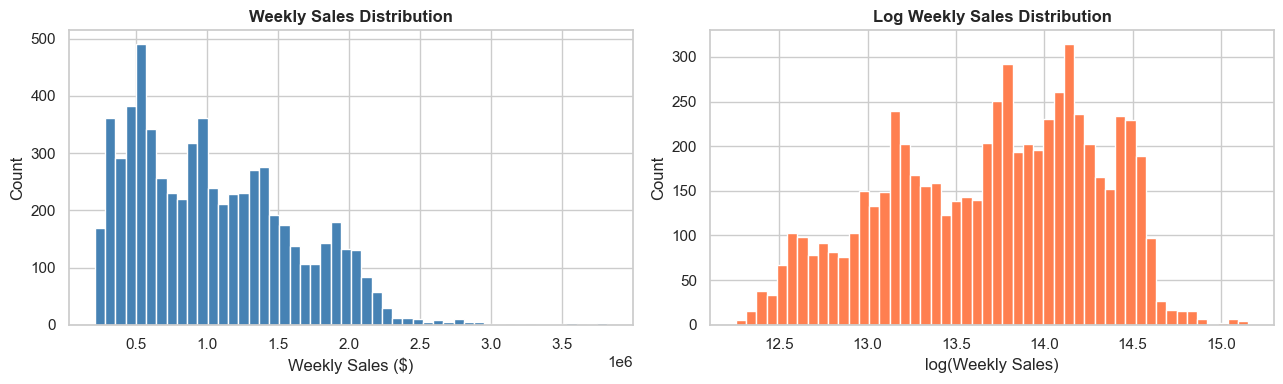

In [6]:
# weekly sales distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['Weekly_Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Weekly Sales Distribution', fontweight='bold')
axes[0].set_xlabel('Weekly Sales ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['Weekly_Sales']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Log Weekly Sales Distribution', fontweight='bold')
axes[1].set_xlabel('log(Weekly Sales)')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

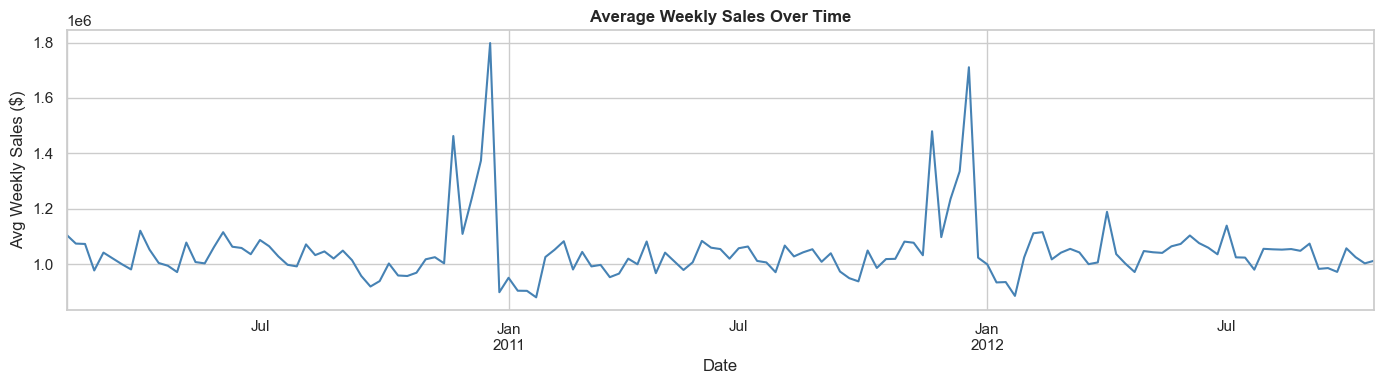

In [7]:
# average weekly sales over time
sales_by_date = df.groupby('Date')['Weekly_Sales'].mean()

fig, ax = plt.subplots(figsize=(14, 4))
sales_by_date.plot(ax=ax, color='steelblue')
ax.set_title('Average Weekly Sales Over Time', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Weekly Sales ($)')
plt.tight_layout()
plt.show()

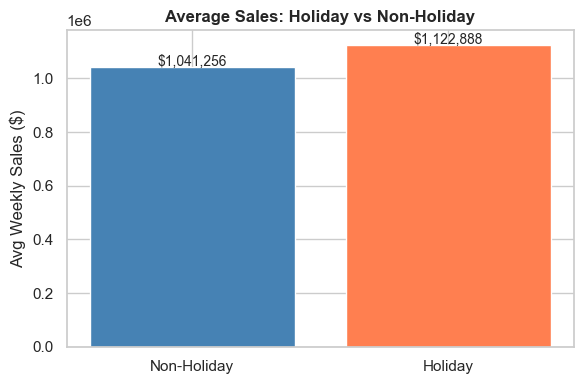

In [8]:
# holiday vs non-holiday sales
fig, ax = plt.subplots(figsize=(6, 4))
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
ax.bar(['Non-Holiday', 'Holiday'], holiday_sales.values, color=['steelblue', 'coral'])
ax.set_title('Average Sales: Holiday vs Non-Holiday', fontweight='bold')
ax.set_ylabel('Avg Weekly Sales ($)')
for i, v in enumerate(holiday_sales.values):
    ax.text(i, v + 5000, f'${v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

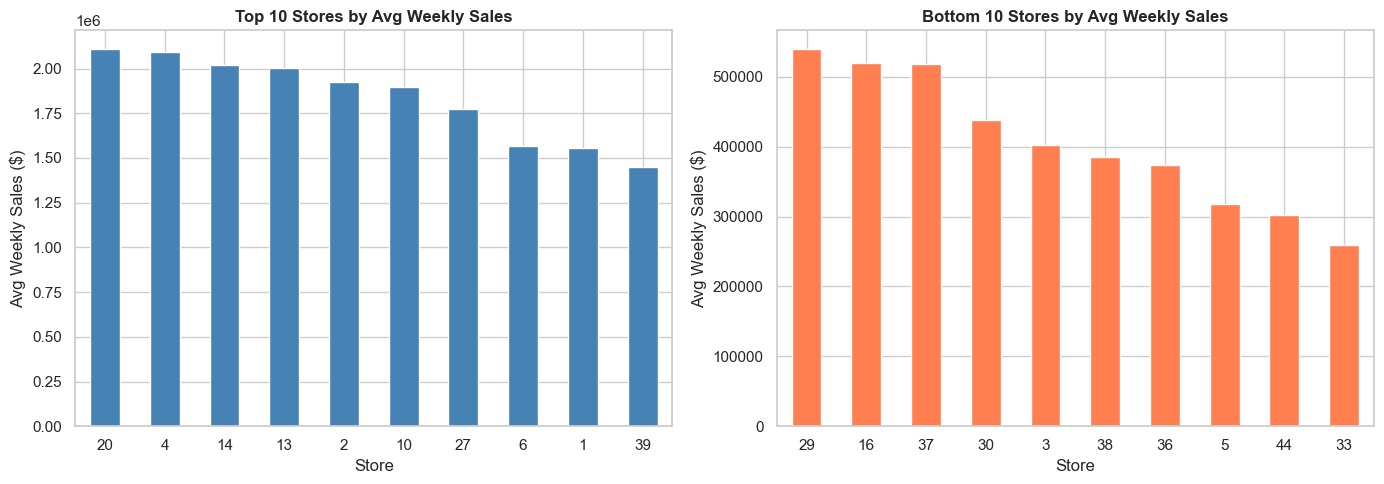

In [9]:
# sales by store (top 10 and bottom 10)
store_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
store_sales.head(10).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Stores by Avg Weekly Sales', fontweight='bold')
axes[0].set_xlabel('Store')
axes[0].set_ylabel('Avg Weekly Sales ($)')
axes[0].tick_params(axis='x', rotation=0)

store_sales.tail(10).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Bottom 10 Stores by Avg Weekly Sales', fontweight='bold')
axes[1].set_xlabel('Store')
axes[1].set_ylabel('Avg Weekly Sales ($)')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

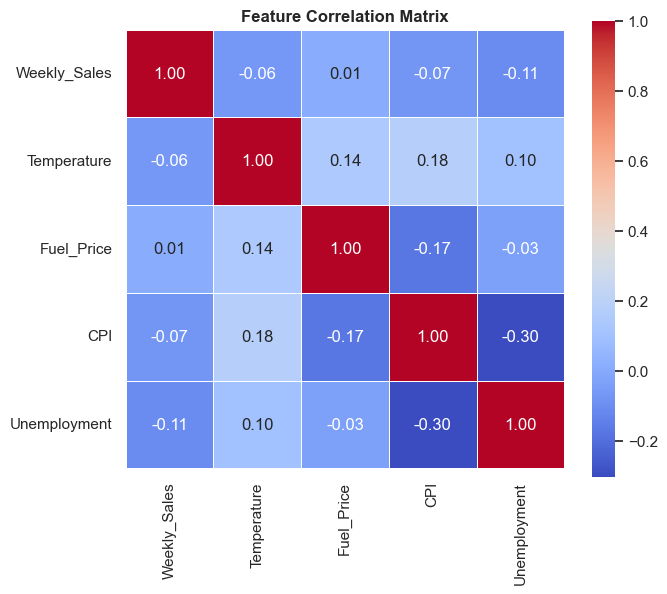

In [10]:
# feature correlations
num_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [11]:
# date features
df['Year']        = df['Date'].dt.year
df['Month']       = df['Date'].dt.month
df['Quarter']     = df['Date'].dt.quarter
df['Week']        = df['Date'].dt.isocalendar().week.astype(int)
df['Day']         = df['Date'].dt.day
df['DayOfWeek']   = df['Date'].dt.dayofweek
df['IsWeekend']   = (df['DayOfWeek'] >= 5).astype(int)

print('Date features added')

Date features added


In [12]:
# lag and rolling features per store
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

for lag in [1, 2, 4, 12]:
    df[f'Lag_{lag}'] = df.groupby('Store')['Weekly_Sales'].shift(lag)

for window in [4, 12]:
    grp = df.groupby('Store')['Weekly_Sales']
    df[f'Rolling_Mean_{window}'] = grp.shift(1).rolling(window).mean().reset_index(0, drop=True)
    df[f'Rolling_Std_{window}']  = grp.shift(1).rolling(window).std().reset_index(0, drop=True)
    df[f'Rolling_Max_{window}']  = grp.shift(1).rolling(window).max().reset_index(0, drop=True)
    df[f'Rolling_Min_{window}']  = grp.shift(1).rolling(window).min().reset_index(0, drop=True)

df['Expanding_Mean'] = df.groupby('Store')['Weekly_Sales'].shift(1).expanding().mean().reset_index(0, drop=True)

# drop rows with NaN introduced by lags
df = df.dropna().reset_index(drop=True)
print(f'Shape after feature engineering: {df.shape}')
print('New features:', [c for c in df.columns if c not in ['Store','Date','Weekly_Sales','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment']])

Shape after feature engineering: (5895, 28)
New features: ['Year', 'Month', 'Quarter', 'Week', 'Day', 'DayOfWeek', 'IsWeekend', 'Lag_1', 'Lag_2', 'Lag_4', 'Lag_12', 'Rolling_Mean_4', 'Rolling_Std_4', 'Rolling_Max_4', 'Rolling_Min_4', 'Rolling_Mean_12', 'Rolling_Std_12', 'Rolling_Max_12', 'Rolling_Min_12', 'Expanding_Mean']


In [13]:
# define features and target
DROP_COLS = ['Date', 'Weekly_Sales']
FEATURES  = [c for c in df.columns if c not in DROP_COLS]
TARGET    = 'Weekly_Sales'

X = df[FEATURES].values
y = df[TARGET].values

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'X: {X.shape}  y: {y.shape}')

Features (26): ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Quarter', 'Week', 'Day', 'DayOfWeek', 'IsWeekend', 'Lag_1', 'Lag_2', 'Lag_4', 'Lag_12', 'Rolling_Mean_4', 'Rolling_Std_4', 'Rolling_Max_4', 'Rolling_Min_4', 'Rolling_Mean_12', 'Rolling_Std_12', 'Rolling_Max_12', 'Rolling_Min_12', 'Expanding_Mean']
X: (5895, 26)  y: (5895,)


In [14]:
# train / test split (no shuffle - respect time order)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=False
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# scale
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Scaling done')

Train: (4716, 26)  |  Test: (1179, 26)
Scaling done


## 5. Model Training

In [15]:
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=150, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE
    ),
    'Ridge Regression': Ridge(
        alpha=1.0
    ),
    'KNN': KNeighborsRegressor(
        n_neighbors=7, metric='euclidean', n_jobs=-1
    ),
}

print('Models defined:')
for name in models:
    print(f'  - {name}')

Models defined:
  - Random Forest
  - Gradient Boosting
  - Ridge Regression
  - KNN


In [16]:
results = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_sc, y_train)

    y_pred = model.predict(X_test_sc)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)

    cv_r2  = cross_val_score(model, X_train_sc, y_train, cv=5,
                             scoring='r2', n_jobs=-1)

    results[name] = {
        'model':   model,
        'y_pred':  y_pred,
        'mae':     mae,
        'rmse':    rmse,
        'r2':      r2,
        'cv_mean': cv_r2.mean(),
        'cv_std':  cv_r2.std(),
    }
    print(f'  MAE  : ${mae:,.0f}')
    print(f'  RMSE : ${rmse:,.0f}')
    print(f'  R2   : {r2:.4f}')
    print(f'  CV R2: {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
    print()

Training Random Forest...
  MAE  : $43,903
  RMSE : $66,722
  R2   : 0.9714
  CV R2: 0.9649 +/- 0.0187

Training Gradient Boosting...
  MAE  : $42,579
  RMSE : $63,477
  R2   : 0.9741
  CV R2: 0.9655 +/- 0.0158

Training Ridge Regression...
  MAE  : $61,832
  RMSE : $96,717
  R2   : 0.9400
  CV R2: 0.9272 +/- 0.0285

Training KNN...
  MAE  : $103,666
  RMSE : $133,842
  R2   : 0.8850
  CV R2: 0.8856 +/- 0.0750



## 6. Model Comparison

In [17]:
# summary table
summary = pd.DataFrame([
    {
        'Model':    name,
        'MAE ($)':  f"{r['mae']:,.0f}",
        'RMSE ($)': f"{r['rmse']:,.0f}",
        'R2':       f"{r['r2']:.4f}",
        'CV R2 Mean': f"{r['cv_mean']:.4f}",
        'CV R2 Std':  f"{r['cv_std']:.4f}",
    }
    for name, r in results.items()
])
summary = summary.sort_values('R2', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

            Model MAE ($) RMSE ($)     R2 CV R2 Mean CV R2 Std
Gradient Boosting  42,579   63,477 0.9741     0.9655    0.0158
    Random Forest  43,903   66,722 0.9714     0.9649    0.0187
 Ridge Regression  61,832   96,717 0.9400     0.9272    0.0285
              KNN 103,666  133,842 0.8850     0.8856    0.0750


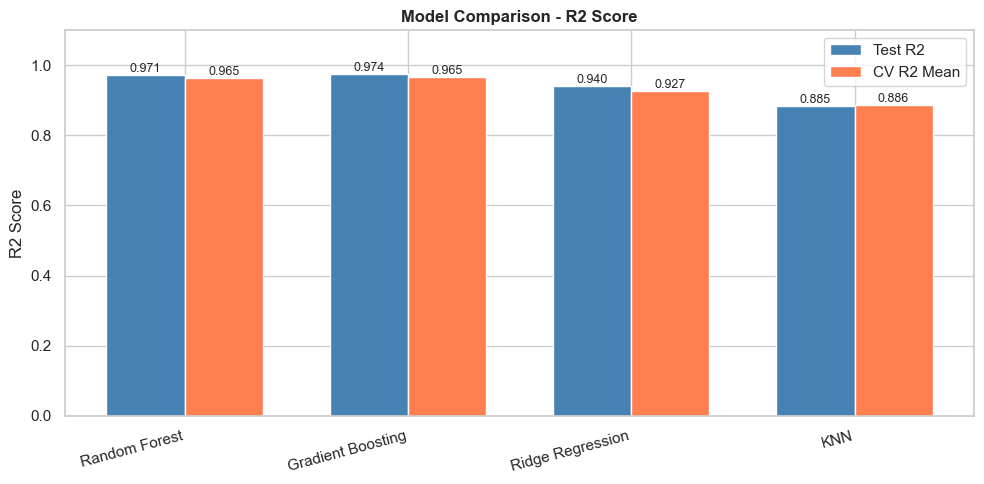

In [18]:
# comparison bar chart
names = list(results.keys())
r2s   = [results[n]['r2']   for n in names]
cvs   = [results[n]['cv_mean'] for n in names]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, r2s, w, label='Test R2',   color='steelblue')
ax.bar(x + w/2, cvs, w, label='CV R2 Mean', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('R2 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison - R2 Score', fontweight='bold')
ax.legend()
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.3f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [19]:
# select best model by R2
best_name   = max(results, key=lambda n: results[n]['r2'])
best_result = results[best_name]
best_model  = best_result['model']

print(f'Best model : {best_name}')
print(f'MAE        : ${best_result["mae"]:,.0f}')
print(f'RMSE       : ${best_result["rmse"]:,.0f}')
print(f'R2         : {best_result["r2"]:.4f}')

Best model : Gradient Boosting
MAE        : $42,579
RMSE       : $63,477
R2         : 0.9741


## 7. Best Model Evaluation

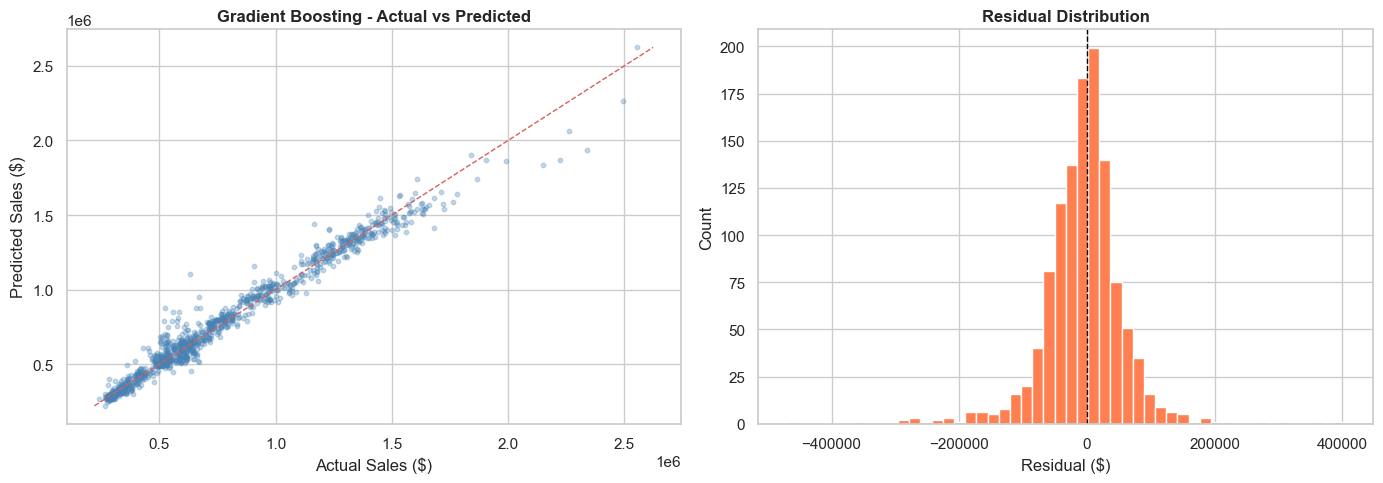

In [20]:
# actual vs predicted
y_pred = best_result['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual Sales ($)')
axes[0].set_ylabel('Predicted Sales ($)')
axes[0].set_title(f'{best_name} - Actual vs Predicted', fontweight='bold')

residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

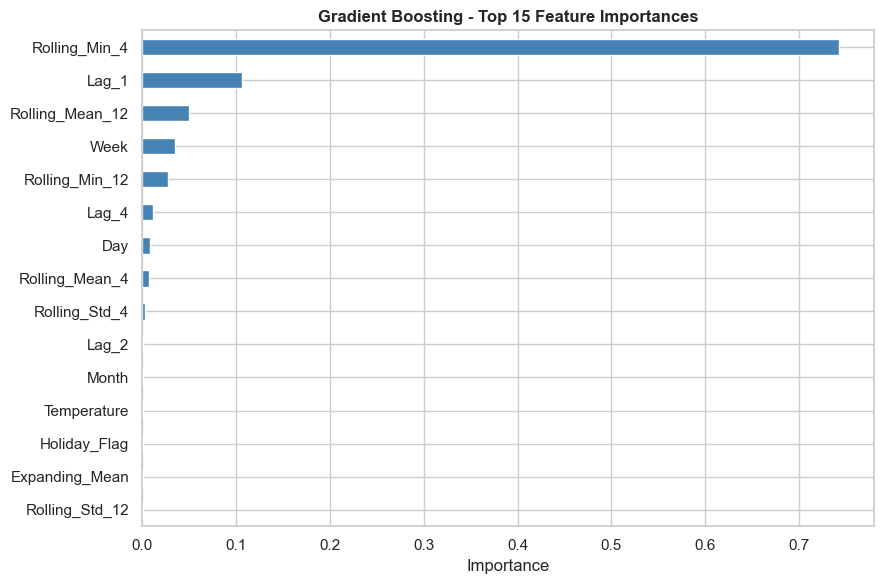

In [21]:
# feature importances (tree-based only)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True).tail(15)
    fig, ax = plt.subplots(figsize=(9, 6))
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{best_name} - Top 15 Feature Importances', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_name} does not have feature_importances_. Skipping.')

## 8. Save Best Model Artifacts

In [22]:
# save scaler
with open(MODELS_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('scaler.pkl saved')

# save best model
with open(MODELS_DIR / 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f'best_model.pkl saved  ({best_name})')

# save metadata
metadata = {
    'features':   FEATURES,
    'target':     TARGET,
    'best_model': best_name,
    'mae':        float(best_result['mae']),
    'rmse':       float(best_result['rmse']),
    'r2':         float(best_result['r2']),
    'cv_mean':    float(best_result['cv_mean']),
    'cv_std':     float(best_result['cv_std']),
    'n_train':    int(X_train.shape[0]),
    'n_test':     int(X_test.shape[0]),
    'stores':     sorted(df['Store'].unique().tolist()),
    'all_results': {
        name: {
            'mae':     float(r['mae']),
            'rmse':    float(r['rmse']),
            'r2':      float(r['r2']),
            'cv_mean': float(r['cv_mean']),
            'cv_std':  float(r['cv_std']),
        }
        for name, r in results.items()
    }
}
with open(MODELS_DIR / 'metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print('metadata.pkl saved')

print(f'\nAll artifacts saved to: {MODELS_DIR.resolve()}')

scaler.pkl saved
best_model.pkl saved  (Gradient Boosting)
metadata.pkl saved

All artifacts saved to: /home/prasanna/Desktop/Projects/sales-forecasting/models


In [23]:
# sanity check
with open(MODELS_DIR / 'best_model.pkl', 'rb') as f:
    m = pickle.load(f)
with open(MODELS_DIR / 'scaler.pkl', 'rb') as f:
    s = pickle.load(f)
with open(MODELS_DIR / 'metadata.pkl', 'rb') as f:
    meta = pickle.load(f)

sample    = X_test[:1]
sample_sc = s.transform(sample)
pred      = m.predict(sample_sc)[0]

print(f'Best model : {meta["best_model"]}')
print(f'R2         : {meta["r2"]:.4f}')
print(f'MAE        : ${meta["mae"]:,.0f}')
print(f'Sample prediction: ${pred:,.0f}')
print('Sanity check passed')

Best model : Gradient Boosting
R2         : 0.9741
MAE        : $42,579
Sample prediction: $491,822
Sanity check passed
